# Notebook to do Exposure time calculations because the script seems to encounter errors with Multiprocessing?

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import proper
import roman_preflight_proper
from corgisim import scene, instrument

In [2]:
# Ensure we have the Proper model
roman_preflight_proper.copy_here()

# USER INPUTS
Vmag = 1.9
spectral_type = 'G0V'
cgi_mode = 'excam'
bandpass_corgisim = '1F'
cor_type = 'hlc'
output_dim = 51
rootname = 'hlc_ni_3e-8'
pixscale_mas = 21.8 # mas/pix

# Set up a mask at the IWA
pixscale_rad = pixscale_mas / 1e3 / 206265
pixscale_lamD = 2.4 / 575e-9 * pixscale_rad
array_center = output_dim // 2
mask = np.zeros([output_dim, output_dim])
rad = pixscale_lamD * output_dim / 2
x = np.linspace(-rad, rad, output_dim)
x, y = np.meshgrid(x, x)
r = np.hypot(y, x)
mask[r <= 5] = 1
mask[r <= 3] = 0

# Init scene
host_star_properties = {
    'Vmag': Vmag,
    'spectral_type': spectral_type,
    'magtype': 'vegamag'
}
base_scene = scene.Scene(host_star_properties, point_source_info=None)

# init dms
dm1 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm1_v.fits' )
dm2 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm2_v.fits' )

# Init instrument
optics_keywords = {
        'cor_type':cor_type,
        'use_errors':2,
        'polaxis':10,
        'output_dim':output_dim,
        'prism':'POL0',
        'use_dm1':1,
        'dm1_v':dm1,
        'use_dm2':1,
        'dm2_v':dm2,
        'use_fpm':1,
        'use_lyot_stop':1,
        'use_field_stop':1
}

# Remember to clear polarized scenes
polarized_scenes = []
for prism in ['POL0', 'POL45']:

    # Swap the wollaston prism
    optics_keywords['prism'] = prism
    print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
    
    # re-init optics and generate the PSF
    optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
    sim_scene = optics.get_host_star_psf(base_scene)
    polarized_scenes.append(sim_scene)

sim_scene_Q = polarized_scenes[0]
sim_scene_U = polarized_scenes[1]

Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.


In [3]:
np.log10(2)

np.float64(0.3010299956639812)

[10000.         13335.21432163 17782.79410039 23713.73705662
 31622.77660168]


Running Experment for Different Gains:   0%|                                                                                                                                                  | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_291124/3670447409.py:71: RuntimeWarning: invalid value encountered in divide
  q_multiplier = (q_img / DoLP) ** 2
/tmp/ipykernel_291124/3670447409.py:72: RuntimeWarning: invalid value encountered in divide
  u_multiplier = (u_img / DoLP) ** 2
Running Experment for Different Gains: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [16:08<00:00, 193.78s/it]


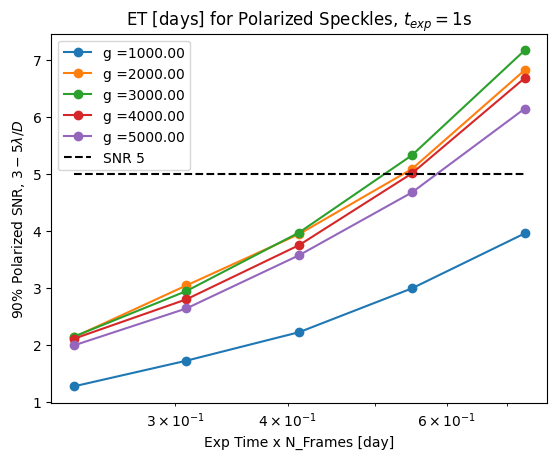

In [7]:
from tqdm import tqdm
n_frames = np.logspace(4, 4.5, 5)
print(n_frames)
single_texp = 1 # seconds
cr_rate = 0 # Keeping zero for purposes of this simulation
photon_counting = True
s_to_day = 1.15741e-5
plot_intermediates = False


# Gains in the range of 1000 -> 5000
if photon_counting:
    gains = np.arange(1000, 6000, 1000)#np.logspace(3, 3.69, 5)

# Keep gains below 1000 for non photon counting mode
else:
    gains = np.logspace(0, 3, 10)


plt.figure()
plt.title("ET [days] for Polarized Speckles, "+r"$t_{exp}=$"+f"{single_texp}s")
for gain in tqdm(gains, desc="Running Experment for Different Gains"):

    mean_Qs = []
    mean_Us = []
    mean_DoLPs = []

    
    # Re-initialize detector
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=photon_counting)
    
    for N_FRAMES in n_frames:

        N_FRAMES = int(N_FRAMES)
            
        # Re-sample scene from flux map
        I0, I90 = detector.generate_photon_counted_detector_image(sim_scene_Q, single_texp, N_FRAMES)
        
        # Get variance estimates from the image stack
        var_I0 = np.var(detector._image_stack_00, axis=0)
        var_I90 = np.var(detector._image_stack_90, axis=0)
        
        # Re-sample scene from flux map
        I45, I135 = detector.generate_photon_counted_detector_image(sim_scene_U, single_texp, N_FRAMES)
        
        # Get variance estimates from the image stack
        var_I45 = np.var(detector._image_stack_00, axis=0)
        var_I135 = np.var(detector._image_stack_90, axis=0)

        # Return to units of e-
        I0 *= N_FRAMES
        I90 *= N_FRAMES
        I45 *= N_FRAMES
        I135 *= N_FRAMES
        
        q_img = I0 - I90
        u_img = I45 - I135
        i_img = I0 + I90
    
        # Propagate uncertainty
        var_q = var_I0 + var_I90
        var_u = var_I45 + var_I135
        
        # Compute polarized intensity
        DoLP = np.sqrt(q_img**2 + u_img**2)
        
        # Propagate Uncertainty
        q_multiplier = (q_img / DoLP) ** 2
        u_multiplier = (u_img / DoLP) ** 2
        var_DoLP = q_multiplier * var_q + u_multiplier * var_u
        DoLP /= np.sqrt(var_DoLP)

        # Find max signal in near-IWA annulus
        mean_dolp = np.nanpercentile(DoLP[mask==1], 90)

        # Append to the DoLPs list for plotting
        mean_DoLPs.append(mean_dolp)
    
        if plot_intermediates:

            # Regenerate the working angle patches for plotting
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            im1 = axes[0].imshow(I0, origin='lower')
            axes[0].set_title(f'0 deg image with noise, hlc \n t = {single_texp * s_to_day}d')
            axes[0].add_patch(IWA)
            axes[0].add_patch(OWA)
            fig.colorbar(im1, ax=axes[0], shrink=0.7)
    
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
            
            im2 = axes[1].imshow(I90, origin='lower')
            axes[1].set_title(f'90 deg image with noise, hlc \n t = {single_texp * s_to_day}d')
            axes[1].add_patch(IWA)
            axes[1].add_patch(OWA)
            fig.colorbar(im2, ax=axes[1], shrink=0.7)

        
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
            
            im3 = axes[2].imshow(DoLP, origin='lower', cmap="Spectral", vmin=1, vmax=9)
            axes[2].set_title('DoLP image, hlc')
            axes[2].add_patch(IWA)
            axes[2].add_patch(OWA)
            fig.colorbar(im3, ax=axes[2], shrink=0.7, label="SNR")
            
            plt.tight_layout()
            plt.show()


    # Begin plotting standard deviation of polarized intensity in annulus
    # Multiply by 2 to account for separate Q and U exposures
    plt.plot(n_frames * s_to_day * 2 * single_texp, mean_DoLPs, marker="o", label=f"g ={gain:.2f}")

plt.xscale("log")
plt.xlabel("Exp Time x N_Frames [day]")
plt.ylabel(r"$90\%$"+" Polarized SNR, "+r"$3-5\lambda/D$")
plt.plot(n_frames * s_to_day * 2 * single_texp, np.ones_like(mean_DoLPs) * 5, color="k", linestyle="dashed", label="SNR 5")
plt.legend()
plt.show()

# Plot images for a single case

In [ ]:
n_frames

In [ ]:
gain = 5000
texp = 20
nframe = int(n_frames[-1]) #int(n_frames[10]) + 1 # single frame

# Init (and later clear) the stacks of images
I0 = []
I90 = []
I45 = []
I135 = []

for n in tqdm(range(nframe), desc=f"Running Single Observation g={gain}, t={texp}"):

    # Re-initialize detector
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=False)

    # Re-sample scene from flux map
    sim_scene_Q_det = detector.generate_detector_image(sim_scene_Q, texp)
    sim_scene_U_det = detector.generate_detector_image(sim_scene_U, texp)
    
    image_tot_corgi_sub_0 = sim_scene_Q_det.image_on_detector.data[0].astype(np.float64)
    image_tot_corgi_sub_90 = sim_scene_Q_det.image_on_detector.data[1].astype(np.float64)

    image_tot_corgi_sub_45 = sim_scene_U_det.image_on_detector.data[0].astype(np.float64)
    image_tot_corgi_sub_135 = sim_scene_U_det.image_on_detector.data[1].astype(np.float64)

    I0.append(image_tot_corgi_sub_0)
    I90.append(image_tot_corgi_sub_90)
    I45.append(image_tot_corgi_sub_45)
    I135.append(image_tot_corgi_sub_135)

# Collapse and convert to polarized quantities
med_I0 = np.nanmedian(I0, axis=0)
med_I90 = np.nanmedian(I90, axis=0)
med_I45 = np.nanmedian(I45, axis=0)
med_I135 = np.nanmedian(I135, axis=0)

var_I0 = np.nanvar(I0, axis=0)
var_I90 = np.nanvar(I90, axis=0)
var_I45 = np.nanvar(I45, axis=0)
var_I135 = np.nanvar(I135, axis=0)

med_Q = med_I0 - med_I90
var_Q = var_I0 + var_I90

med_U = med_I45 - med_I135
var_U = var_I45 + var_I135

med_DoLP = np.sqrt(med_Q**2 + med_U**2)

Q_scaling = (med_Q / med_DoLP) ** 2
U_scaling = (med_U / med_DoLP) ** 2
var_DoLP = Q_scaling * var_Q + U_scaling * var_U

In [ ]:
plt.figure(figsize=[12, 2])
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.title(f"I0 frame={i+1}")
    plt.imshow(I0[i])
    plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
    plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
    plt.colorbar()
plt.show()

plt.figure(figsize=[3, 2])
plt.imshow(np.sqrt(var_I0))
plt.colorbar()
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.show()

In [ ]:
# Regenerate the working angle patches for plotting
IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im1 = axes[0].imshow(med_I0, origin='lower')
axes[0].set_title(f'0 deg image with noise, hlc \n t = {texp * nframe * s_to_day * 2:.2e}d')
axes[0].add_patch(IWA)
axes[0].add_patch(OWA)
fig.colorbar(im1, ax=axes[0], shrink=0.7)

IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

im2 = axes[1].imshow(med_I90, origin='lower')
axes[1].set_title(f'90 deg image with noise, hlc \n t = {texp * nframe * s_to_day * 2:.2e}d')
axes[1].add_patch(IWA)
axes[1].add_patch(OWA)
fig.colorbar(im2, ax=axes[1], shrink=0.7)


IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

im3 = axes[2].imshow(med_DoLP / np.sqrt(var_DoLP), origin='lower', cmap="Spectral", vmin=1, vmax=9)
axes[2].set_title('DoLP image, hlc \n' +r'<$q_{counts}$>' + f' ={mean_q}, {mean_q / np.median(i_img):.2e}%')
axes[2].add_patch(IWA)
axes[2].add_patch(OWA)
fig.colorbar(im3, ax=axes[2], shrink=0.7, label="SNR")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
plt.subplot(121)
plt.imshow(q_img)
plt.colorbar()
plt.subplot(122)
plt.imshow(u_img)
plt.colorbar()

plt.figure(figsize=[10,3])
plt.subplot(121)
plt.imshow(DoLP / mask, cmap="Spectral")
plt.colorbar(label="Polarized Intensity SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(122)
plt.imshow(np.sqrt(var_DoLP))
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=[10, 4])
space = "    "
plt.suptitle(r"$V_{mag}=$"+f"{Vmag}"+space+r"$t_{exp}=$"+f"{single_texp}s"+space+r"$g=$"+f"{gain}"+space+r"$N_{frames}=$"+f"{N_FRAMES}")
plt.subplot(121)
plt.title("Median"+r"$(I_{90})$")
plt.imshow(np.median(I0, axis=0))
plt.colorbar()
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)

plt.subplot(122)
plt.title(r"$\sigma^2 (I_{90})$")
plt.imshow(np.var(I0, axis=0))
plt.colorbar(label="counts")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.show()

In [ ]:
single_texp * N_FRAMES * s_to_day

In [ ]:
plt.imshow(I0[0])

In [ ]:
plt.imshow(DoLP)
plt.colorbar()

In [ ]:
plt.imshow(DoLP / np.sqrt(var_DoLP))
plt.colorbar()

In [ ]:
plt.plot(var_dolps)